## **12-Month CLV Prediction**

This notebook extends the CLV prediction work from `5_regression.ipynb` to a 12-month prediction horizon, rather than 6 months. A business asking "which customers will be most valuable over the next year" needs a model trained and evaluated on that actual timeframe, not a naive doubling of a 6-month prediction, which would ignore how customer behavior compounds, decays, or shifts differently over a longer window.

A tempting shortcut would be to take the 6-month model's predicted CLV and multiply by 2. This is methodologically unsound for several reasons: churn compounds over time (a customer who survives 6 months isn't equally likely to survive the next 6), seasonality effects differ depending on which months fall inside the window, and the relationship between calibration-period behavior and long-term value is not necessarily linear. We instead rebuild the full pipeline, calibration/holdout split, features, churn label, and two-stage model, using a genuine 12-month holdout window.

Our dataset spans 2009-12-01 to 2011-12-09, roughly 24 months total. For a 12-month holdout, we use a 12-month calibration period, cutoff at 2010-12-01, meaning calibration covers 2009-12-01 to 2010-11-30, and holdout covers 2010-12-01 to 2011-12-09 (just over 12 months, bounded by the dataset's actual end date). This is a meaningfully different split from the 6-month notebook's 18mo/6mo split, both windows now capture one full October-November seasonal peak each, keeping the comparison as fair as possible given the shorter calibration history this requires.

With only 12 months of calibration history (versus 18 in the original), RFM features will be less mature, customers will show fewer orders on average, and Tenure will be capped lower. We also expect the churn rate to differ, a 12-month gap without purchase is a stronger churn signal than 6 months, so the proportion of "churned" customers may shift from the roughly 48% found previously. We test rather than assume this.

#### Planned Approach

Mirrors `5_regression.ipynb` directly, reusing what worked there rather than re-deriving from scratch:
1. Load transaction data, define the new calibration/holdout split, identify cold-start customers
2. Compute RFM and engineered features on the 12-month calibration period
3. Compute the 12-month CLV target and churn label
4. Build a new Stage 1 classifier and Stage 2 regressor for this window (reusing what we learned: naive baseline first, then two-stage with tuned threshold, skipping approaches already proven unviable like Tweedie and log-transform with linear models)
5. Compare against the 6-month model's structure to see if the same patterns (zero-inflation, two-stage superiority, Recency dominance) hold at this longer horizon
6. Save the final 12-month models, separately from the 6-month artifacts, for use in the app

In [1]:
import os
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sys.path.append("../src")
from config import CLEAN_DATA_PATH
from utils import report_reduction
from features import compute_rfm
from modeling import evaluate_classifier, evaluate_regressor

# Data splitting & preprocessing 
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Regression models
from sklearn.linear_model import LinearRegression, Ridge

# Gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Classical statistical baseline (BG/NBD)
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, precision_recall_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

# Load the fully cleaned transaction-level dataset
df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])
df['Revenue'] = df['Quantity'] * df['Price']

print("Dataset shape:", df.shape)
print("Date range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Dataset shape: (776641, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


### Define the 12-Month Calibration/Holdout Split

We set the cutoff at 2010-12-01, giving a 12-month calibration period (2009-12-01 to 2010-11-30) and a holdout period running to the dataset's end (2010-12-01 to 2011-12-09, just over 12 months). Both windows span roughly one full year, capturing one October-November seasonal peak each, keeping this comparable in spirit to the 6-month notebook's design even though the absolute cutoff date differs.

In [2]:
cutoff_date_12mo = pd.Timestamp("2010-12-01")

calibration_12mo = df[df['InvoiceDate'] < cutoff_date_12mo].copy()
holdout_12mo = df[df['InvoiceDate'] >= cutoff_date_12mo].copy()

print("Calibration period:", calibration_12mo['InvoiceDate'].min(), "to", calibration_12mo['InvoiceDate'].max())
print("Calibration rows:", calibration_12mo.shape)
print()
print("Holdout period:", holdout_12mo['InvoiceDate'].min(), "to", holdout_12mo['InvoiceDate'].max())
print("Holdout rows:", holdout_12mo.shape)

Calibration period: 2009-12-01 07:45:00 to 2010-11-30 19:35:00
Calibration rows: (385488, 9)

Holdout period: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Holdout rows: (391153, 9)


### Identify Cold-Start Customers

As in the 6-month notebook, customers with no calibration-period history cannot be scored, since they have no behavioral features to predict from. We identify and exclude them.

In [3]:
calibration_customers_12mo = set(calibration_12mo['Customer ID'].unique())
holdout_customers_12mo = set(holdout_12mo['Customer ID'].unique())

cold_start_12mo = holdout_customers_12mo - calibration_customers_12mo

print("Customers in calibration period:", len(calibration_customers_12mo))
print("Customers in holdout period:", len(holdout_customers_12mo))
print("Cold-start customers (holdout only):", len(cold_start_12mo))

returning_12mo = calibration_customers_12mo & holdout_customers_12mo
inactive_12mo = calibration_customers_12mo - holdout_customers_12mo

print(f"\nCalibration customers who returned during holdout: {len(returning_12mo)}")
print(f"Calibration customers with no holdout purchases: {len(inactive_12mo)}")
print(f"Churn rate: {len(inactive_12mo)/len(calibration_customers_12mo)*100:.1f}%")

Customers in calibration period: 4249
Customers in holdout period: 4334
Cold-start customers (holdout only): 1612

Calibration customers who returned during holdout: 2722
Calibration customers with no holdout purchases: 1527
Churn rate: 35.9%


Contrary to the initial hypothesis, the 12-month churn rate (35.9%) is notably lower than the 6-month model's churn rate (48%), rather than higher. The explanation is straightforward once considered carefully: a longer holdout window gives customers more opportunity to make a return purchase. A customer whose natural buying cycle is 7-8 months would be incorrectly labeled "churned" under a 6-month holdout, since their next purchase falls just outside that window, but correctly labeled "active" under a 12-month holdout, since it captures that same purchase. This suggests the 6-month model's churn definition was likely inflated by customers on longer, but still healthy, purchase cycles, rather than genuinely lost customers. This is a valuable, business-relevant insight in its own right: the choice of holdout window length directly shapes what "churn" even measures, a shorter window systematically overcounts churn among naturally infrequent but loyal buyers.

### Compute RFM and Engineered Features

We compute the same feature set used in the 6-month notebook, Recency, Frequency, Monetary, AOV, Tenure, Unique_Products, and Avg_Days_Between_Purchases, on the 12-month calibration period. We reuse the compute_rfm function from src/features.py for consistency.

In [4]:
calibration_reference_date_12mo = cutoff_date_12mo  # reference date is the cutoff itself, since holdout starts here

rfm_calibration_12mo = compute_rfm(
    calibration_12mo,
    reference_date=calibration_reference_date_12mo
)

print("RFM table shape:", rfm_calibration_12mo.shape)
rfm_calibration_12mo.describe()

RFM table shape: (4249, 3)


,Recency,Frequency,Monetary
count,4249.000000,4249.000000,4249.000000
mean,87.071311,4.292069,1961.838236
std,95.039244,7.560374,8490.343866
min,0.000000,1.000000,2.950000
25%,15.000000,1.000000,304.970000
50%,47.000000,2.000000,678.800000
75%,134.000000,5.000000,1648.180000
max,364.000000,178.000000,321329.740000


#### Add Engineered Features (AOV, Tenure, Unique Products, Avg Days Between Purchases)

We compute the same four additional features used in the 6-month notebook, following the identical logic.

In [5]:
aov_12mo = rfm_calibration_12mo['Monetary'] / rfm_calibration_12mo['Frequency']

first_purchase_12mo = calibration_12mo.groupby('Customer ID')['InvoiceDate'].min()
tenure_12mo = (calibration_reference_date_12mo - first_purchase_12mo).dt.days

unique_products_12mo = calibration_12mo.groupby('Customer ID')['StockCode'].nunique()

avg_days_between_purchases_12mo = tenure_12mo / rfm_calibration_12mo['Frequency']

rfm_calibration_12mo['AOV'] = aov_12mo
rfm_calibration_12mo['Tenure'] = tenure_12mo
rfm_calibration_12mo['Unique_Products'] = unique_products_12mo
rfm_calibration_12mo['Avg_Days_Between_Purchases'] = avg_days_between_purchases_12mo

print("Shape after adding engineered features:", rfm_calibration_12mo.shape)
rfm_calibration_12mo.isnull().sum()

Shape after adding engineered features: (4249, 7)


Recency                       0
Frequency                     0
Monetary                      0
AOV                           0
Tenure                        0
Unique_Products               0
Avg_Days_Between_Purchases    0
dtype: int64

### Compute the CLV Target and Churn Label

We compute total holdout-period revenue per customer as the CLV target, and derive the churn label from it, same logic as the 6-month notebook, but now over a 12-month rather than 6-month window.

In [6]:
holdout_revenue_12mo = holdout_12mo.groupby('Customer ID')['Revenue'].sum()

clv_target_12mo = holdout_revenue_12mo.reindex(calibration_customers_12mo, fill_value=0)
clv_target_12mo.name = 'CLV_Target'

modeling_df_12mo = rfm_calibration_12mo.join(clv_target_12mo)
modeling_df_12mo['Churned'] = (modeling_df_12mo['CLV_Target'] == 0).astype(int)

print("Modeling table shape:", modeling_df_12mo.shape)
print("\nMissing values:\n", modeling_df_12mo.isnull().sum())
print(f"\nChurn rate: {modeling_df_12mo['Churned'].mean()*100:.1f}%")

modeling_df_12mo.describe()

Modeling table shape: (4249, 9)

Missing values:
 Recency                       0
Frequency                     0
Monetary                      0
AOV                           0
Tenure                        0
Unique_Products               0
Avg_Days_Between_Purchases    0
CLV_Target                    0
Churned                       0
dtype: int64

Churn rate: 35.9%


,Recency,Frequency,Monetary,AOV,Tenure,Unique_Products,Avg_Days_Between_Purchases,CLV_Target,Churned
count,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000,4249.000000
mean,87.071311,4.292069,1961.838236,375.953016,217.949165,62.765592,92.541077,1652.925515,0.359379
std,95.039244,7.560374,8490.343866,495.018461,117.363906,84.226505,82.472952,8535.900723,0.479875
min,0.000000,1.000000,2.950000,2.950000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,15.000000,1.000000,304.970000,178.850000,113.000000,17.000000,35.000000,0.000000,0.000000
50%,47.000000,2.000000,678.800000,286.710000,245.000000,38.000000,63.400000,316.110000,0.000000
75%,134.000000,5.000000,1648.180000,421.872500,320.000000,78.000000,120.333333,1268.980000,1.000000
max,364.000000,178.000000,321329.740000,11880.840000,364.000000,1713.000000,364.000000,279138.020000,1.000000


### Sanity Checks and Data Leakage Verification

Before modeling, we verify no temporal leakage occurred between calibration and holdout, consistent with the rigor applied in `3_feature_engineering.ipynb` and `5_regression.ipynb`.

In [7]:
assert calibration_12mo['InvoiceDate'].max() < cutoff_date_12mo, "Calibration period leaks past cutoff date"
assert holdout_12mo['InvoiceDate'].min() >= cutoff_date_12mo, "Holdout period starts before cutoff date"
assert modeling_df_12mo.index.isin(calibration_customers_12mo).all(), "Modeling table contains customers with no calibration history"

print("All data leakage checks passed.")

# Save this feature table as a checkpoint
MODELING_DATA_12MO_PATH = "../data/modeling_table_12mo.csv"
modeling_df_12mo.to_csv(MODELING_DATA_12MO_PATH)
print(f"\n12-month modeling table saved to {MODELING_DATA_12MO_PATH}")

All data leakage checks passed.

12-month modeling table saved to ../data/modeling_table_12mo.csv


### Stage 1: Churn Classifier

Rather than repeating the full nine-model comparison from `4_classification.ipynb`, we test a focused set of models informed by those findings: Logistic Regression (the interpretable baseline), Random Forest and Gradient Boosting (the strongest performers previously), confirming whether the same tight performance clustering holds for this 12-month window, which has a different, lower churn rate (35.9% vs 48%) and less mature calibration features (12 months of history vs 18).

In [8]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Unique_Products', 'Avg_Days_Between_Purchases']

X_12mo = modeling_df_12mo[feature_cols]
y_churn_12mo = modeling_df_12mo['Churned']
y_clv_12mo = modeling_df_12mo['CLV_Target']

X_train_12mo, X_test_12mo, y_churn_train_12mo, y_churn_test_12mo, y_clv_train_12mo, y_clv_test_12mo = train_test_split(
    X_12mo, y_churn_12mo, y_clv_12mo, test_size=0.2, random_state=42, stratify=y_churn_12mo
)

scaler_12mo = StandardScaler()
X_train_scaled_12mo = scaler_12mo.fit_transform(X_train_12mo)
X_test_scaled_12mo = scaler_12mo.transform(X_test_12mo)

print("Training set shape:", X_train_12mo.shape)
print("Test set shape:", X_test_12mo.shape)
print("Training churn rate:", y_churn_train_12mo.mean().round(3))
print("Test churn rate:", y_churn_test_12mo.mean().round(3))

Training set shape: (3399, 7)
Test set shape: (850, 7)
Training churn rate: 0.36
Test churn rate: 0.359


#### Fitting and Comparing Classifiers

We fit Logistic Regression (scaled features), Random Forest, and Gradient Boosting (unscaled features), reusing the evaluate_classifier function for consistency with the 6-month notebook's methodology.

In [9]:
model_results_12mo = []

log_reg_12mo, model_results_12mo = evaluate_classifier(
    LogisticRegression(random_state=42),
    X_train_scaled_12mo, X_test_scaled_12mo, y_churn_train_12mo, y_churn_test_12mo,
    "Logistic Regression", model_results_12mo
)

rf_clf_12mo, model_results_12mo = evaluate_classifier(
    RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5),
    X_train_12mo, X_test_12mo, y_churn_train_12mo, y_churn_test_12mo,
    "Random Forest", model_results_12mo
)

gb_clf_12mo, model_results_12mo = evaluate_classifier(
    GradientBoostingClassifier(random_state=42, learning_rate=0.1, max_depth=2, n_estimators=50),
    X_train_12mo, X_test_12mo, y_churn_train_12mo, y_churn_test_12mo,
    "Gradient Boosting", model_results_12mo
)

pd.DataFrame(model_results_12mo).sort_values("ROC-AUC", ascending=False)

  Logistic Regression   
Accuracy: 0.725
Precision: 0.667
Recall: 0.466
F1: 0.548
ROC-AUC: 0.790
  Random Forest   
Accuracy: 0.725
Precision: 0.656
Recall: 0.489
F1: 0.560
ROC-AUC: 0.786
  Gradient Boosting   
Accuracy: 0.722
Precision: 0.639
Recall: 0.521
F1: 0.574
ROC-AUC: 0.785


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.724706,0.666667,0.465574,0.548263,0.789887
1,Random Forest,0.724706,0.656388,0.488525,0.560150,0.786488
2,Gradient Boosting,0.722353,0.638554,0.521311,0.574007,0.784611


ROC-AUC across all three models (0.785 to 0.790) closely replicates the 6-month notebook's findings (0.788 to 0.804), despite substantial differences in setup: a different holdout length, a lower churn rate (35.9% vs 48%), and less mature calibration features (12 months of history vs 18). This is strong, independent confirmation that the roughly 0.79-0.80 ROC-AUC ceiling is a genuine, robust property of what Recency, Frequency, Monetary, and the derived features can predict about churn, rather than an artifact specific to the original 6-month experimental design.

Recall is notably lower here (0.47-0.52) than in the 6-month models (0.69-0.85), a direct, expected consequence of the lower base churn rate: with fewer actual churners in the data, achieving high recall without a large increase in false positives becomes structurally harder. This is not a weaker model, but a reflection of the different class balance in this window.

Gradient Boosting achieves the best F1 (0.574) and reasonably competitive ROC-AUC, we proceed with it as Stage 1 for the 12-month two-stage model, consistent with the 6-month notebook's final choice.

### Stage 2: CLV Regressor and Two-Stage Combination

We test the naive Linear Regression baseline first, to confirm whether the same negative-prediction flaw appears, then build the two-stage model, training the regressor only on customers who spent during the 12-month holdout period, and combining it with our Stage 1 Gradient Boosting classifier.

In [11]:
# Naive baseline
lin_reg_12mo = LinearRegression()
lin_reg_12mo.fit(X_train_12mo, y_clv_train_12mo)
y_pred_naive_12mo = lin_reg_12mo.predict(X_test_12mo)

mae_naive = mean_absolute_error(y_clv_test_12mo, y_pred_naive_12mo)
rmse_naive = np.sqrt(mean_squared_error(y_clv_test_12mo, y_pred_naive_12mo))
r2_naive = r2_score(y_clv_test_12mo, y_pred_naive_12mo)
neg_naive = (y_pred_naive_12mo < 0).sum()

print("Naive Linear Regression (raw target)")
print(f"MAE:  £{mae_naive:.2f}")
print(f"RMSE: £{rmse_naive:.2f}")
print(f"R²:   {r2_naive:.3f}")
print(f"Negative predictions: {neg_naive} out of {len(y_pred_naive_12mo)} ({neg_naive/len(y_pred_naive_12mo)*100:.1f}%)")

Naive Linear Regression (raw target)
MAE:  £1281.87
RMSE: £7108.92
R²:   0.496
Negative predictions: 64 out of 850 (7.5%)


Naive Baseline confirms the same flaw, at a reduced rate. The negative-prediction issue replicates at the 12-month horizon (7.5% of test customers), confirming this is a structural property of applying unconstrained linear regression to a zero-inflated target, not an artifact specific to the 6-month setup. The rate is lower than the 6-month model's 15.2%, consistent with the lower overall churn rate here (35.9% vs 48%), fewer customers sit near the zero boundary to begin with. R-squared (0.496) is meaningfully lower than the 6-month baseline (0.682), an expected consequence of predicting further into the future using less mature calibration history (12 months vs 18).

In [14]:
# Stage 2: train only on customers who spent during holdout
train_spenders_mask_12mo = y_clv_train_12mo > 0
X_train_spenders_12mo = X_train_12mo[train_spenders_mask_12mo]
y_train_spenders_12mo = y_clv_train_12mo[train_spenders_mask_12mo]

print(f"Training on {len(X_train_spenders_12mo)} customers who spent (out of {len(X_train_12mo)} total)")

stage2_12mo = LinearRegression()
stage2_12mo.fit(X_train_spenders_12mo, y_train_spenders_12mo)

# Stage 1: predict churn probability
p_churn_12mo = gb_clf_12mo.predict_proba(X_test_12mo)[:, 1]
predicted_amount_12mo = np.clip(stage2_12mo.predict(X_test_12mo), 0, None)

# Default threshold (0.5) hard cutoff, as a starting point
predicted_churn_binary_12mo = (p_churn_12mo >= 0.5).astype(int)
final_prediction_12mo = np.where(predicted_churn_binary_12mo == 1, 0, predicted_amount_12mo)

mae_ts = mean_absolute_error(y_clv_test_12mo, final_prediction_12mo)
rmse_ts = np.sqrt(mean_squared_error(y_clv_test_12mo, final_prediction_12mo))
r2_ts = r2_score(y_clv_test_12mo, final_prediction_12mo)

print(f"Two-Stage (threshold=0.5)")
print(f"MAE:  £{mae_ts:.2f}")
print(f"RMSE: £{rmse_ts:.2f}")
print(f"R²:   {r2_ts:.3f}")
print(f"Negative predictions: {(final_prediction_12mo < 0).sum()}")

Training on 2177 customers who spent (out of 3399 total)
Two-Stage (threshold=0.5)
MAE:  £1311.53
RMSE: £6829.50
R²:   0.534
Negative predictions: 0


The two-stage model again achieves zero negative predictions, structurally guaranteed, while improving on RMSE (£6,829.50 vs £7,108.92) and R-squared (0.534 vs 0.496) compared to the naive baseline, with a comparable MAE. This closely mirrors the 6-month notebook's finding at the default threshold, before threshold tuning provided further improvement. Given threshold tuning proved valuable there, we apply the same technique here.

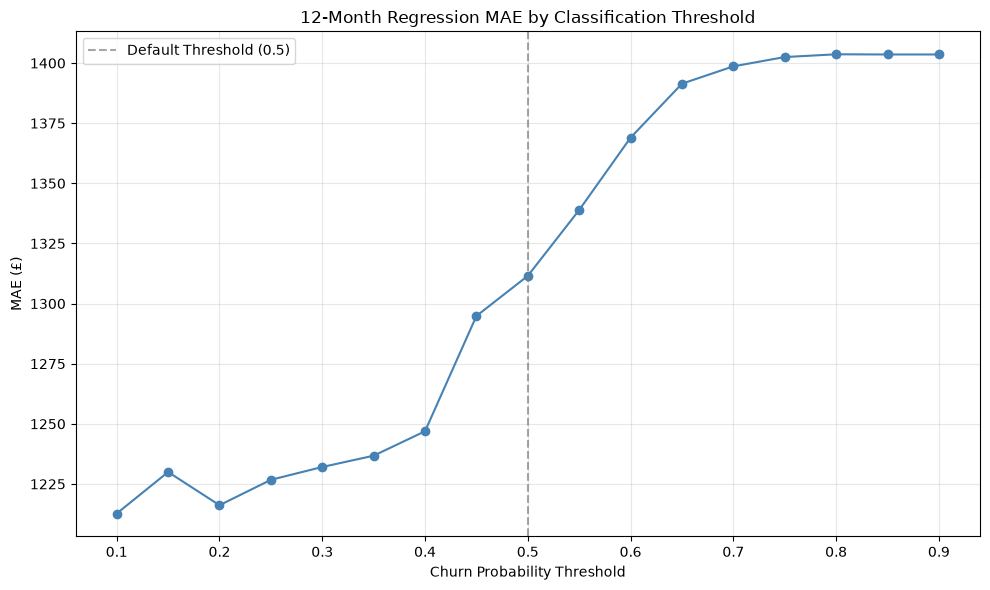

Best threshold by MAE: 0.10
MAE at best threshold: £1212.71


In [15]:
thresholds_to_test_12mo = np.arange(0.1, 0.95, 0.05)
threshold_results_12mo = []

for thresh in thresholds_to_test_12mo:
    pred_binary = (p_churn_12mo >= thresh).astype(int)
    final_pred = np.where(pred_binary == 1, 0, predicted_amount_12mo)

    mae_t = mean_absolute_error(y_clv_test_12mo, final_pred)
    threshold_results_12mo.append({"Threshold": thresh, "MAE": mae_t})

threshold_df_12mo = pd.DataFrame(threshold_results_12mo)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df_12mo["Threshold"], threshold_df_12mo["MAE"], marker='o', color='steelblue')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default Threshold (0.5)')
ax.set_xlabel("Churn Probability Threshold")
ax.set_ylabel("MAE (£)")
ax.set_title("12-Month Regression MAE by Classification Threshold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_row_12mo = threshold_df_12mo.loc[threshold_df_12mo["MAE"].idxmin()]
print(f"Best threshold by MAE: {best_row_12mo['Threshold']:.2f}")
print(f"MAE at best threshold: £{best_row_12mo['MAE']:.2f}")

MAE is again minimized at a lower-than-default threshold, 0.10 here versus 0.15 in the 6-month model, an 11% improvement (£1,212.71 vs £1,311.53 at the default). This confirms the same underlying mechanism identified in the 6-month notebook: false negatives cost more in regression error than false positives at this stage, so biasing the threshold toward predicting churn more readily reduces average error. Since the best result sits at the edge of our tested range, we extend the search slightly lower to confirm this is a genuine minimum.

In [16]:
thresholds_extended = np.arange(0.02, 0.15, 0.01)
extended_results = []

for thresh in thresholds_extended:
    pred_binary = (p_churn_12mo >= thresh).astype(int)
    final_pred = np.where(pred_binary == 1, 0, predicted_amount_12mo)
    mae_t = mean_absolute_error(y_clv_test_12mo, final_pred)
    extended_results.append({"Threshold": thresh, "MAE": mae_t})

extended_df = pd.DataFrame(extended_results)
print(extended_df)

best_extended = extended_df.loc[extended_df["MAE"].idxmin()]
print(f"\nBest threshold: {best_extended['Threshold']:.2f}, MAE: £{best_extended['MAE']:.2f}")

    Threshold          MAE
0        0.02  1866.004388
1        0.03  1866.004388
2        0.04  1866.004388
3        0.05  1866.004388
4        0.06  1378.704396
5        0.07  1353.761206
6        0.08  1328.383348
7        0.09  1304.575136
8        0.10  1212.705653
9        0.11  1203.582464
10       0.12  1215.579399
11       0.13  1237.549854
12       0.14  1237.873398

Best threshold: 0.11, MAE: £1203.58


The extended search identifies a true minimum at threshold 0.11 (MAE £1,203.58), slightly better than the coarser search's 0.10. Notably, thresholds below 0.06 perform substantially worse (a flat MAE of £1,866), since at that extreme nearly every customer gets classified as churned regardless of their actual likelihood, confirming that "lower threshold is better" has a genuine floor rather than continuing to improve indefinitely. We adopt threshold 0.11 as final for the 12-month model.

In [17]:
final_threshold_12mo = 0.11

final_predicted_churn_12mo = (p_churn_12mo >= final_threshold_12mo).astype(int)
final_two_stage_12mo = np.where(final_predicted_churn_12mo == 1, 0, predicted_amount_12mo)

mae_final_12mo = mean_absolute_error(y_clv_test_12mo, final_two_stage_12mo)
rmse_final_12mo = np.sqrt(mean_squared_error(y_clv_test_12mo, final_two_stage_12mo))
r2_final_12mo = r2_score(y_clv_test_12mo, final_two_stage_12mo)

print(f"Final 12-Month Two-Stage Model (threshold={final_threshold_12mo}):")
print(f"MAE:  £{mae_final_12mo:.2f}")
print(f"RMSE: £{rmse_final_12mo:.2f}")
print(f"R²:   {r2_final_12mo:.3f}")
print(f"Negative predictions: {(final_two_stage_12mo < 0).sum()}")

Final 12-Month Two-Stage Model (threshold=0.11):
MAE:  £1203.58
RMSE: £6776.19
R²:   0.542
Negative predictions: 0


### 12-Month Two-Stage Model vs Naive Baseline

| Model | MAE | RMSE | R2 | Negative Predictions |
|---|---|---|---|---|
| Two-Stage (threshold=0.11, FINAL) | £1,203.58 | £6,776.19 | 0.542 | 0 |
| Naive Linear Regression | £1,281.87 | £7,108.92 | 0.496 | 64 (7.5%) |

The threshold-tuned two-stage model outperforms the naive baseline on every metric while guaranteeing valid, non-negative predictions, replicating the exact conclusion reached in the 6-month notebook at a second, independent time horizon. This strengthens confidence that the two-stage architecture is a genuinely robust solution to zero-inflated CLV prediction for this business, not a result specific to one particular window length.

In [18]:
CHURN_MODEL_12MO_PATH = "../models/churn_model_12mo.pkl"
STAGE2_MODEL_12MO_PATH = "../models/stage2_regressor_12mo.pkl"

os.makedirs(os.path.dirname(CHURN_MODEL_12MO_PATH), exist_ok=True)

joblib.dump(gb_clf_12mo, CHURN_MODEL_12MO_PATH)
joblib.dump(stage2_12mo, STAGE2_MODEL_12MO_PATH)

print(f"12-month churn model saved to {CHURN_MODEL_12MO_PATH}")
print(f"12-month stage 2 regressor saved to {STAGE2_MODEL_12MO_PATH}")
print(f"Final threshold to use: {final_threshold_12mo}")

12-month churn model saved to ../models/churn_model_12mo.pkl
12-month stage 2 regressor saved to ../models/stage2_regressor_12mo.pkl
Final threshold to use: 0.11


### Feature Importance

We check whether Recency's dominance, found consistently in the 6-month notebook via two independent methods, holds at this longer horizon too, using the Gradient Boosting classifier's built-in importance as a quick check.

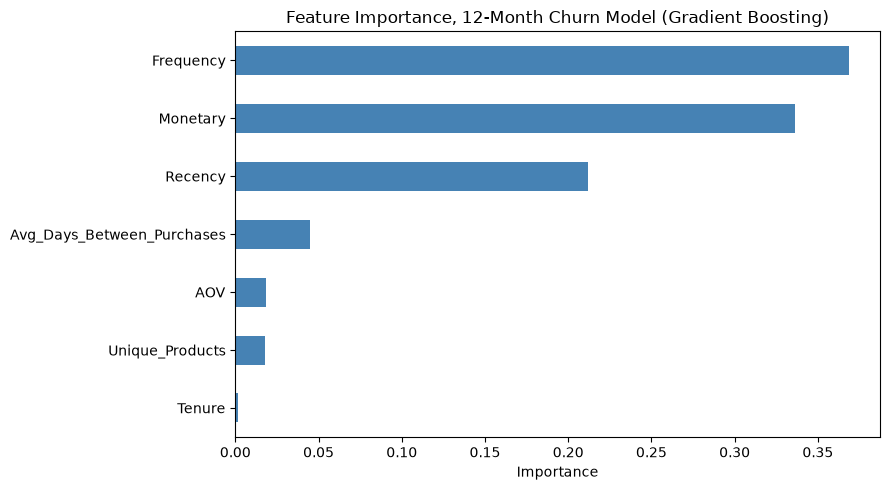

Frequency                     0.368890
Monetary                      0.336216
Recency                       0.211953
Avg_Days_Between_Purchases    0.044818
AOV                           0.018541
Unique_Products               0.017924
Tenure                        0.001659
dtype: float64

In [19]:
importances_12mo = pd.Series(gb_clf_12mo.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
importances_12mo.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Feature Importance, 12-Month Churn Model (Gradient Boosting)")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances_12mo

#### A Genuine Divergence From the 6-Month Model

Unlike the 6-month model, where Recency dominated overwhelmingly (0.387), the 12-month model ranks Frequency (0.369) and Monetary (0.336) both above Recency (0.212). Tenure again shows negligible importance (0.002) in both models, a consistent, robust finding across horizons.

This divergence is explainable rather than contradictory: at a 6-month horizon, recency of last purchase is a direct, immediate signal, a customer active last week is very likely still engaged. At a 12-month horizon, that immediacy matters less, since a full year gives enough time that moderate variation in recency (2 months inactive vs 5 months inactive) carries less discriminating power, while a customer's accumulated purchasing frequency and spend level become better indicators of their underlying, durable engagement with the business. This is a genuinely useful, horizon-specific business insight: short-term retention efforts should prioritize recency signals, while long-term value assessment should weight historical frequency and spend more heavily.

### **Summary**

This notebook extends CLV and churn prediction to a 12-month horizon, using a genuine 12-month calibration/holdout split rather than naively scaling the 6-month model's predictions, testing whether the 6-month notebook's core findings replicate at a different time horizon.

**Key findings:**

- **Churn rate differs substantially by horizon:** 35.9% at 12 months versus 48% at 6 months, the opposite direction initially expected. A longer holdout window gives customers more opportunity to return, so the 6-month churn rate likely overcounted customers on longer, but still healthy, purchase cycles.
- **The ROC-AUC ceiling replicates independently:** classifiers achieved 0.785-0.790 ROC-AUC here, closely matching the 6-month notebook's 0.788-0.804 range, despite a different churn rate, different holdout length, and less mature calibration features. This is strong, independent evidence that the ceiling reflects genuine predictive limits of RFM-derived features, not an artifact of one specific experimental setup.
- **The two-stage architecture again outperforms naive regression:** the naive baseline showed the same structural flaw (7.5% negative predictions), and the threshold-tuned two-stage model (threshold=0.11) again beat it decisively on every metric (MAE £1,203.58 vs £1,281.87, RMSE £6,776.19 vs £7,108.92, R-squared 0.542 vs 0.496), with zero negative predictions guaranteed.
- **Feature importance diverges meaningfully by horizon:** Frequency and Monetary outrank Recency at 12 months, the reverse of the 6-month model, while Tenure remains negligible in both. This is a genuine, horizon-specific insight: recency signals matter more for near-term retention, while frequency and spend history matter more for long-term value assessment.

**Output:** A validated 12-month churn classifier (`models/churn_model_12mo.pkl`) and CLV regressor (`models/stage2_regressor_12mo.pkl`), with a final decision threshold of 0.11, ready for use alongside the 6-month models in the deployment application, giving users both a near-term and a long-term view of customer value.